In [1]:
!pip install ultralytics==8.3.148 -q
!pip install albumentations==1.4.0 -q
!pip install seaborn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 18.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.6/123.6 kB 3.4 MB/s eta 0:00:00


In [2]:
import os
import cv2
import yaml
import torch
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ultralytics import YOLO

warnings.filterwarnings("ignore")

print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch Version: 2.10.0+cu128
CUDA Available: True


In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Seed Fixed:", SEED)

Seed Fixed: 42


In [4]:
from sklearn.model_selection import train_test_split
import os
import shutil
from glob import glob

# Dataset Paths

IMAGE_DIR = "/kaggle/input/datasets/mdshamsuddoha45sd34/road-surface-damage-datasetrsdd/data/images"
LABEL_DIR = "/kaggle/input/datasets/mdshamsuddoha45sd34/road-surface-damage-datasetrsdd/data/labels-YOLO"

# Output Dataset Folder

OUTPUT_DIR = "/kaggle/working/road_damage_dataset"

# Create YOLO Folder Structure

folders = [

    "images/train",
    "images/val",
    "images/test",

    "labels/train",
    "labels/val",
    "labels/test"
]

for folder in folders:

    os.makedirs(
        os.path.join(OUTPUT_DIR, folder),
        exist_ok=True
    )

# Get Image Files

image_files = []

for ext in ["*.jpg", "*.png", "*.jpeg"]:

    image_files.extend(
        glob(os.path.join(IMAGE_DIR, ext))
    )

print("Total Images:", len(image_files))

# 70% / 15% / 15%

train_files, temp_files = train_test_split(

    image_files,
    test_size=0.30,
    random_state=42,
    shuffle=True
)

val_files, test_files = train_test_split(

    temp_files,
    test_size=0.50,
    random_state=42,
    shuffle=True
)

print("Train:", len(train_files))
print("Validation:", len(val_files))
print("Test:", len(test_files))

# Copy Images and Labels

def copy_files(file_list, split_name):
    for img_path in file_list:
        file_name = os.path.basename(img_path)
        label_name = os.path.splitext(file_name)[0] + ".txt"
        label_path = os.path.join(
            LABEL_DIR,
            label_name
        )

        # Copy image
        shutil.copy(
            img_path,
            os.path.join(
                OUTPUT_DIR,
                f"images/{split_name}",
                file_name
            )
        )

        # Copy label
        if os.path.exists(label_path):
            shutil.copy(
                label_path,
                os.path.join(
                    OUTPUT_DIR,
                    f"labels/{split_name}",
                    label_name
                )
            )

copy_files(train_files, "train")
copy_files(val_files, "val")
copy_files(test_files, "test")

print("Dataset split completed successfully")

Total Images: 2009
Train: 1406
Validation: 301
Test: 302
Dataset split completed successfully


In [5]:
DATASET_ROOT = "/kaggle/working/road_damage_dataset"

CLASS_NAMES = {
    0: "pothole",
    1: "crack",
    2: "manhole",
}

data_yaml = {
    "path": DATASET_ROOT,
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": CLASS_NAMES
}

with open("data.yaml", "w") as f:
    yaml.dump(data_yaml, f)

print("data.yaml created successfully")

data.yaml created successfully


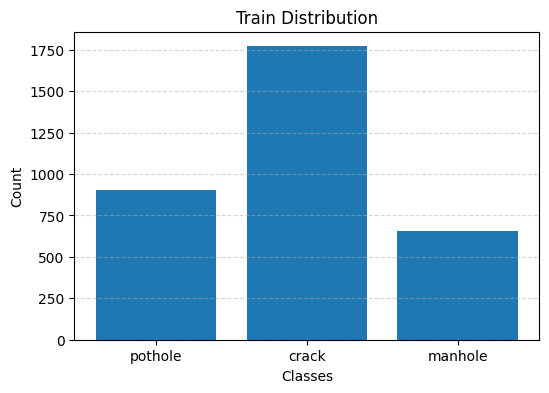

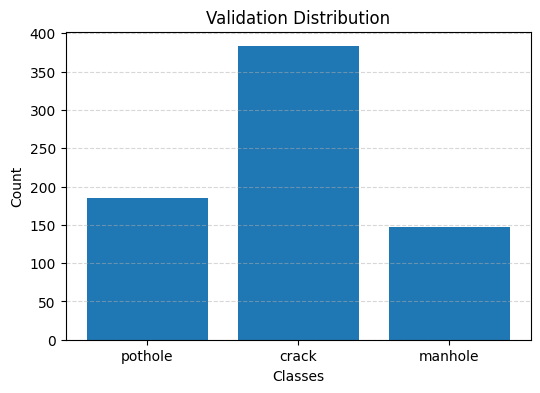

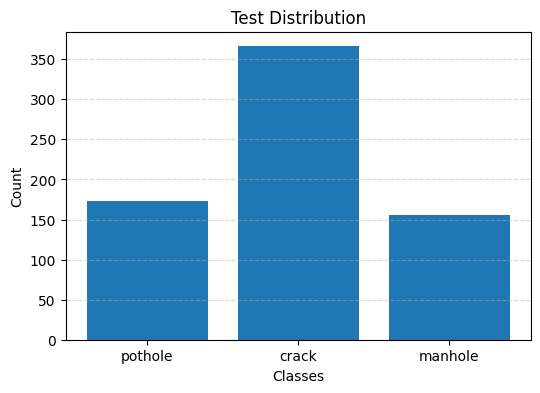

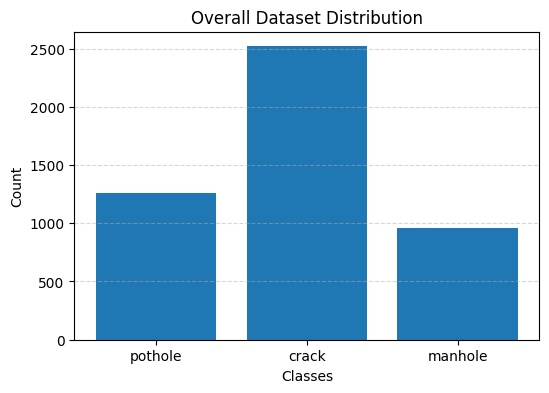

{0: 1261, 1: 2519, 2: 957}


In [6]:
import os
from glob import glob
import matplotlib.pyplot as plt

DATASET_ROOT = "/kaggle/working/road_damage_dataset"
CLASS_NAMES = ["pothole", "crack", "manhole"]

splits = {
    "Train": "labels/train",
    "Validation": "labels/val",
    "Test": "labels/test"
}

total_counts = {0: 0, 1: 0, 2: 0}

for split_name, split_path in splits.items():
    counts = {0: 0, 1: 0, 2: 0}
    for file in glob(os.path.join(DATASET_ROOT, split_path, "*.txt")):
        with open(file, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    cls = int(parts[0])
                    counts[cls] += 1
                    total_counts[cls] += 1

    plt.figure(figsize=(6,4))
    plt.bar(
        CLASS_NAMES,
        counts.values()
    )
    plt.title(f"{split_name} Distribution")
    plt.xlabel("Classes")
    plt.ylabel("Count")
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.show()

# Overall Distribution
plt.figure(figsize=(6,4))
plt.bar(
    CLASS_NAMES,
    total_counts.values()
)
plt.title("Overall Dataset Distribution")
plt.xlabel("Classes")
plt.ylabel("Count")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

print(total_counts)

In [7]:
MODELS = {
    "YOLOv8s": "yolov8s.pt"
}

MODELS

{'YOLOv8s': 'yolov8s.pt'}

In [8]:
import ultralytics
print(ultralytics.__version__)

from ultralytics import YOLO

model = YOLO("yolov8s.pt")

print("Model Loaded Successfully")

8.3.148


100%|██████████| 21.5M/21.5M [00:00<00:00, 162MB/s]


Model Loaded Successfully


In [9]:
results_summary = []

for model_name, model_path in MODELS.items():
    print("Training:", model_name)
    model = YOLO(model_path)
    results = model.train(
        data="data.yaml",

        # Core Training
        epochs=100,
        imgsz=1024,
        batch=12,
        device=0,

        # Optimizer
        optimizer="AdamW",
        lr0=0.0005,
        patience=40,
        cos_lr=True,
        warmup_epochs=5,
        weight_decay=0.0005,

        # Augmentation
        close_mosaic=15,
        mosaic=1.0,
        mixup=0.15,

        scale=0.5,
        translate=0.2,
        fliplr=0.5,
        degrees=3,

        # Lighting robustness 
        hsv_h=0.015,
        hsv_s=0.7,
        hsv_v=0.4,

        # Performance
        cache=True,
        amp=True,
        workers=4,

        # Output
        project="YOLOv8_Road_Damage_Project",
        name=model_name
    )

    results_summary.append({
        "Model": model_name,
        "Status": "Completed"
    })

print(results_summary)

Training: YOLOv8s
New https://pypi.org/project/ultralytics/8.4.116 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.148 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=12, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=15, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=data.yaml, degrees=3, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=YOLOv8s, nbs=64, nms=False, opset=None, optimize=Fals

100%|██████████| 755k/755k [00:00<00:00, 15.7MB/s]


Overriding model.yaml nc=80 with nc=3

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     29056  ultralytics.nn.modules.block.C2f             [64, 64, 1, True]             
  3                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  4                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  5                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  6                  -1  2    788480  ultralytics.nn.modules.block.C2f             [256, 256, 2, True]           
  7                  -1  1   1180672  ultralytics

100%|██████████| 5.35M/5.35M [00:00<00:00, 69.3MB/s]


AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2024.1±659.9 MB/s, size: 88.5 KB)


...

     99/100      6.95G      0.875     0.5222      1.055          6       1024: 100%|██████████| 118/118 [00:56<00:00,  2.10it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 13/13 [00:03<00:00,  3.77it/s]

                   all        301        715      0.632      0.558      0.563      0.255


EarlyStopping: Training stopped early as no improvement observed in last 40 epochs. Best results observed at epoch 59, best model saved as best.pt.
To update EarlyStopping(patience=40) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

99 epochs completed in 1.671 hours.
Optimizer stripped from YOLOv8_Road_Damage_Project/YOLOv8s/weights/last.pt, 22.5MB
Optimizer stripped from YOLOv8_Road_Damage_Project/YOLOv8s/weights/best.pt, 22.5MB

Validating YOLOv8_Road_Damage_Project/YOLOv8s/weights/best.pt...
Ultralytics 8.3.148 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 72 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 13/13 [00:04<00:00,  3.03it/s]


                   all        301        715      0.665       0.53      0.569      0.263
               pothole        115        185      0.624      0.458      0.516      0.205
                 crack        205        383      0.493      0.351      0.346      0.131
               manhole        117        147      0.877      0.782      0.845      0.453
Speed: 0.3ms preprocess, 7.1ms inference, 0.0ms loss, 2.9ms postprocess per image
Results saved to YOLOv8_Road_Damage_Project/YOLOv8s
[{'Model': 'YOLOv8s', 'Status': 'Completed'}]


In [10]:
metrics = model.val()
print(metrics)

Ultralytics 8.3.148 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 72 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2044.1±414.0 MB/s, size: 87.5 KB)


val: Scanning /kaggle/working/road_damage_dataset/labels/val.cache... 301 images, 0 backgrounds, 0 corrupt: 100%|██████████| 301/301 [00:00<?, ?it/s]

WARNING ⚠️ cache='ram' may produce non-deterministic training results. Consider cache='disk' as a deterministic alternative if your disk space allows.



val: Caching images (0.5GB RAM): 100%|██████████| 301/301 [00:00<00:00, 582.76it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 26/26 [00:06<00:00,  4.05it/s]


                   all        301        715      0.665      0.529      0.569      0.264
               pothole        115        185      0.623      0.456      0.515      0.206
                 crack        205        383      0.493       0.35      0.346      0.131
               manhole        117        147      0.878      0.782      0.846      0.455
Speed: 1.3ms preprocess, 15.4ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to YOLOv8_Road_Damage_Project/YOLOv8s2
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7920984e64b0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.01101

In [11]:
results = model.predict(
    source=os.path.join(DATASET_ROOT, "images/test"),
    save=True,
    conf=0.25
)

print("Prediction Completed")


image 1/302 /kaggle/working/road_damage_dataset/images/test/20250219_164838.jpg: 576x1024 1 pothole, 1 crack, 2 manholes, 47.4ms
image 2/302 /kaggle/working/road_damage_dataset/images/test/20250219_165042.jpg: 576x1024 2 potholes, 2 cracks, 20.3ms
image 3/302 /kaggle/working/road_damage_dataset/images/test/20250219_165100.jpg: 576x1024 3 potholes, 2 cracks, 20.3ms
image 4/302 /kaggle/working/road_damage_dataset/images/test/20250219_165339.jpg: 576x1024 1 pothole, 20.3ms
image 5/302 /kaggle/working/road_damage_dataset/images/test/20250219_165709.jpg: 576x1024 1 pothole, 20.3ms
image 6/302 /kaggle/working/road_damage_dataset/images/test/20250219_170531.jpg: 576x1024 1 pothole, 20.3ms
image 7/302 /kaggle/working/road_damage_dataset/images/test/20250219_170838.jpg: 576x1024 2 potholes, 20.3ms
image 8/302 /kaggle/working/road_damage_dataset/images/test/20250219_170909.jpg: 576x1024 1 pothole, 15.8ms
image 9/302 /kaggle/working/road_damage_dataset/images/test/20250223_143954.jpg: 576x1024 1

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Load YOLOv8 training results
results_csv = "/kaggle/working/YOLOv8_Road_Damage_Project/YOLOv8s/results.csv"
df = pd.read_csv(results_csv)
df.head()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,59.8453,2.36229,3.64791,2.10236,0.27312,0.26104,0.19626,0.08648,2.25356,3.17265,1.96400,0.080269,0.000099,0.000099
1,2,120.2670,2.15896,2.59264,1.93748,0.35791,0.35277,0.32094,0.13537,2.19759,2.55569,2.01861,0.060369,0.000199,0.000199
2,3,181.7750,2.09052,2.49816,1.90646,0.33926,0.32140,0.25704,0.10481,2.16758,2.55299,2.03953,0.040468,0.000299,0.000299
3,4,242.8000,2.04044,2.36316,1.88133,0.36033,0.37589,0.32957,0.14229,2.07604,2.45864,2.02505,0.020568,0.000398,0.000398
4,5,303.6260,2.04679,2.28969,1.87721,0.44487,0.43342,0.40360,0.17751,2.08496,2.18098,2.02597,0.000667,0.000497,0.000497


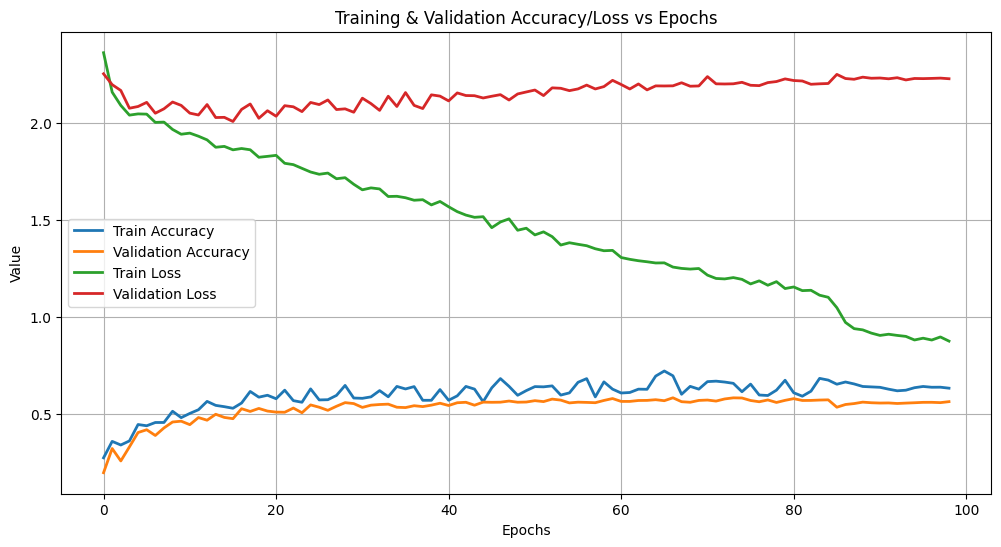

In [13]:

# Create one figure
plt.figure(figsize=(12, 6))

# Accuracy curves
plt.plot(
    df['metrics/precision(B)'],
    label='Train Accuracy',
    linewidth=2
)

plt.plot(
    df['metrics/mAP50(B)'],
    label='Validation Accuracy',
    linewidth=2
)

# Loss curves
plt.plot(
    df['train/box_loss'],
    label='Train Loss',
    linewidth=2
)

plt.plot(
    df['val/box_loss'],
    label='Validation Loss',
    linewidth=2
)

# Labels and title
plt.xlabel('Epochs')
plt.ylabel('Value')
plt.title('Training & Validation Accuracy/Loss vs Epochs')

# Legend and grid
plt.legend()
plt.grid(True)

# Show plot
plt.show()

Total Images Found: 21


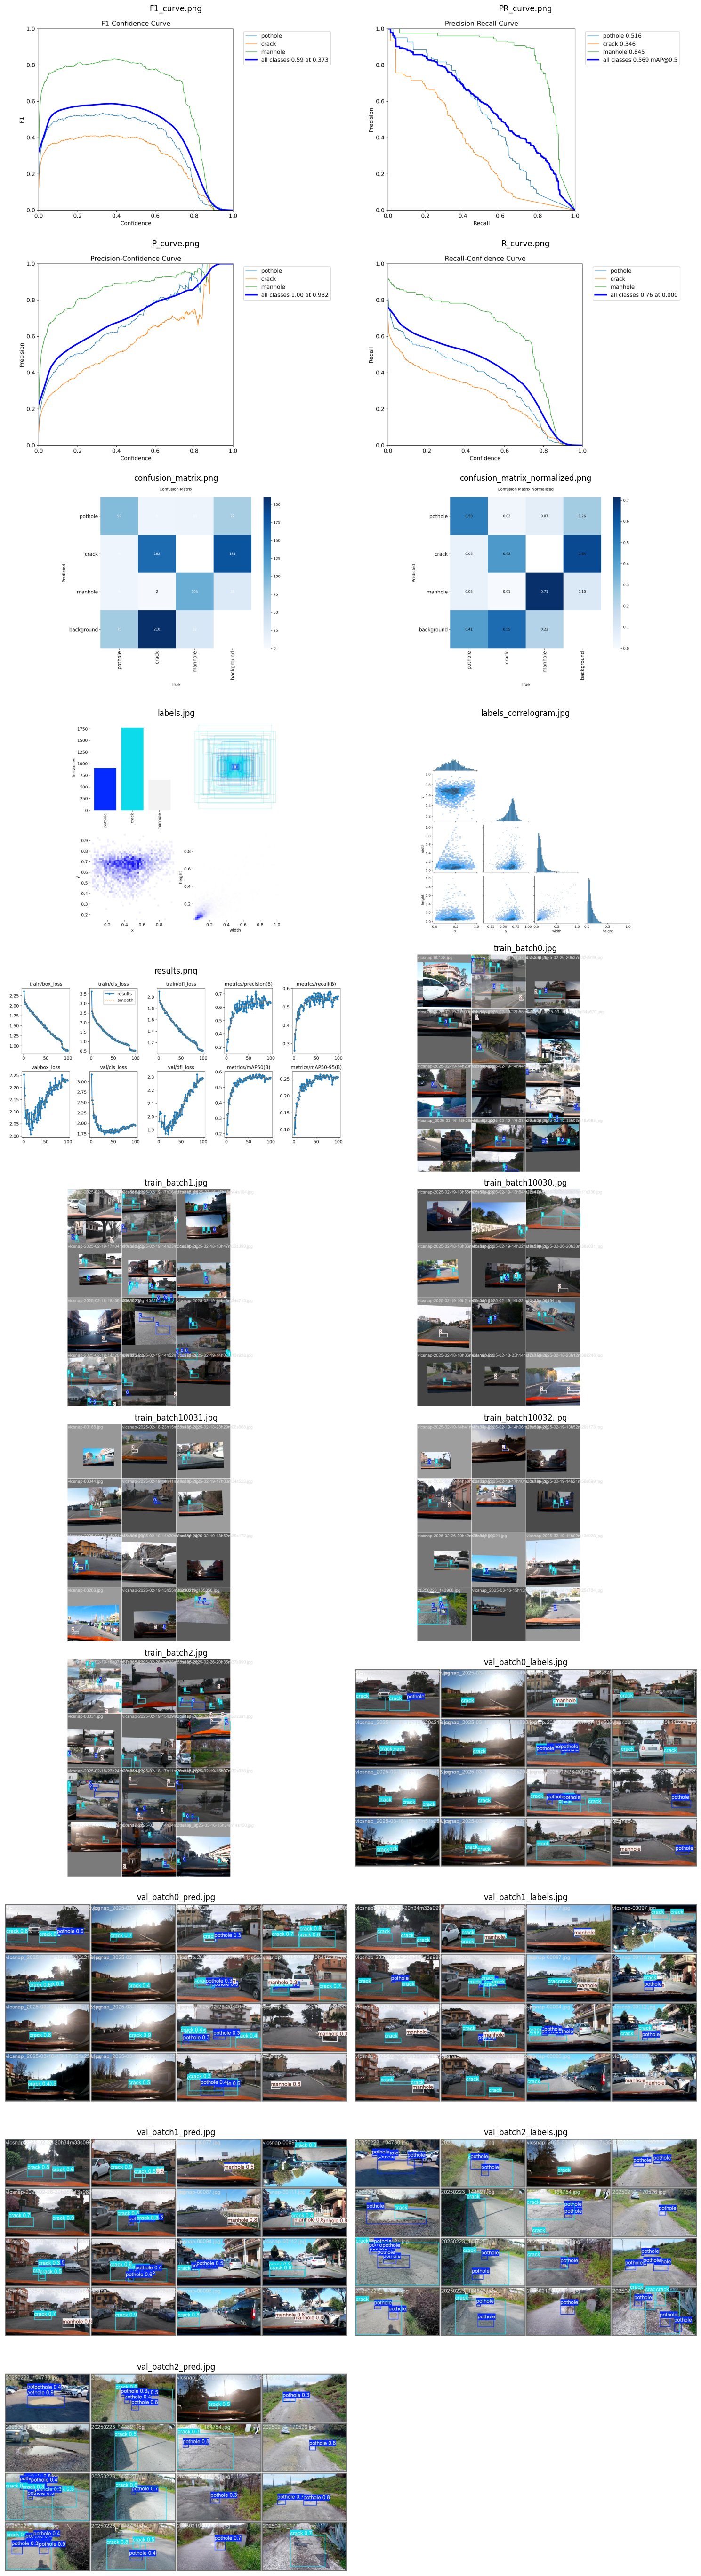

In [14]:
import os
import math
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Folder Path

folder_path = "/kaggle/working/YOLOv8_Road_Damage_Project/YOLOv8s"

# Get All Image Files

image_files = [
    file for file in os.listdir(folder_path)
    if file.lower().endswith(
        (".png", ".jpg", ".jpeg")
    )
]

# Sort files
image_files.sort()

print("Total Images Found:", len(image_files))

# Grid Size

cols = 2

rows = math.ceil(
    len(image_files) / cols
)

# Plot Images

plt.figure(figsize=(15, rows * 5))
for idx, image_name in enumerate(image_files):
    image_path = os.path.join(
        folder_path,
        image_name
    )
    img = mpimg.imread(image_path)
    plt.subplot(rows, cols, idx + 1)
    plt.imshow(img)
    plt.title(image_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

Ultralytics 8.3.148 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 72 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2304.7±509.0 MB/s, size: 92.6 KB)


val: Scanning /kaggle/working/road_damage_dataset/labels/val.cache... 301 images, 0 backgrounds, 0 corrupt: 100%|██████████| 301/301 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 19/19 [00:06<00:00,  2.85it/s]


                   all        301        715      0.665      0.529      0.569      0.264
               pothole        115        185      0.623      0.456      0.515      0.206
                 crack        205        383      0.493       0.35      0.346      0.131
               manhole        117        147      0.878      0.782      0.846      0.455
Speed: 1.5ms preprocess, 14.7ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to runs/detect/val

Per-Class AP
pothole   : 0.2057
crack     : 0.1305
manhole   : 0.4547


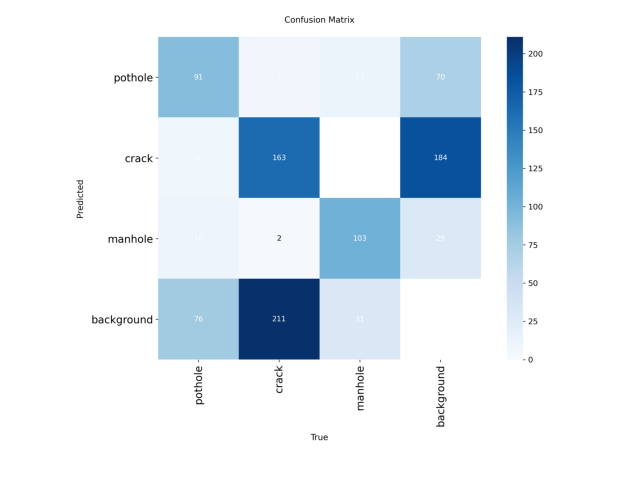

Precision        : 0.6645
Recall           : 0.5294
F1 Score         : 0.5893
mAP@0.5          : 0.5690
mAP@0.5:0.95     : 0.2636
FPS              : 59.97
Latency          : 16.68 ms
Total Parameters : 11,126,745
Trainable Params : 0
Model summary (fused): 72 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs


(72, 11126745, 0, 28.4370432)

In [15]:
from ultralytics import YOLO
from ultralytics.utils.torch_utils import model_info
from PIL import Image
import matplotlib.pyplot as plt
import cv2
import time
import os

best_model = "/kaggle/working/YOLOv8_Road_Damage_Project/YOLOv8s/weights/best.pt"
model = YOLO(best_model)

results = model.val(plots=True)

precision = results.box.mp
recall = results.box.mr
map50 = results.box.map50
map5095 = results.box.map
f1 = 2 * precision * recall / (precision + recall + 1e-16)

print("\nPer-Class AP")
for i, ap in enumerate(results.box.maps):
    print(f"{model.names[i]:10s}: {ap:.4f}")

total_params = sum(p.numel() for p in model.model.parameters())
trainable_params = sum(
    p.numel() for p in model.model.parameters()
    if p.requires_grad
)

image_path = "/kaggle/working/road_damage_dataset/images/val/20250219_164714.jpg"
image = cv2.imread(image_path)

for _ in range(20):
    model.predict(image, verbose=False)

runs = 100

start = time.time()
for _ in range(runs):
    model.predict(image, verbose=False)
end = time.time()

fps = runs / (end - start)
latency = 1000 / fps

cm_path = os.path.join(results.save_dir, "confusion_matrix.png")

if os.path.exists(cm_path):
    plt.figure(figsize=(8, 8))
    plt.imshow(Image.open(cm_path))
    plt.axis("off")
    plt.show()

print(f"Precision        : {precision:.4f}")
print(f"Recall           : {recall:.4f}")
print(f"F1 Score         : {f1:.4f}")
print(f"mAP@0.5          : {map50:.4f}")
print(f"mAP@0.5:0.95     : {map5095:.4f}")
print(f"FPS              : {fps:.2f}")
print(f"Latency          : {latency:.2f} ms")
print(f"Total Parameters : {total_params:,}")
print(f"Trainable Params : {trainable_params:,}")

model_info(model.model)

In [16]:
import os
import zipfile

# Notebook: yolov8s  (plain YOLOv8s)

base = "/kaggle/working"

items = [
    "YOLOv8_Road_Damage_Project",   # train output (YOLOv8s)
    "runs",                         # predict outputs
    "data.yaml",
    "yolov8s.pt"
]

zip_path = "/kaggle/working/yolov8s_outputs.zip"

print("Creating ZIP...")
print("Destination:", zip_path)

with zipfile.ZipFile(
    zip_path,
    "w",
    compression=zipfile.ZIP_DEFLATED,
    compresslevel=6
) as z:

    for item in items:

        path = os.path.join(base, item)

        if not os.path.exists(path):
            print("SKIP - not found:", item)
            continue

        if os.path.isfile(path):
            z.write(path, arcname=item)
            print("Added:", item)

        elif os.path.isdir(path):
            for root, dirs, files in os.walk(path):
                for file in files:
                    full_path = os.path.join(root, file)
                    arcname = os.path.relpath(full_path, base)

                    z.write(full_path, arcname=arcname)

            print("Added folder:", item)

print("\nZIP CREATED SUCCESSFULLY!")

size = os.path.getsize(zip_path) / (1024**3)

print(f"ZIP size: {size:.3f} GB")
print("Path:", zip_path)


Creating ZIP...
Destination: /kaggle/working/yolov8s_outputs.zip
Added folder: YOLOv8_Road_Damage_Project
Added folder: runs
Added: data.yaml
Added: yolov8s.pt

ZIP CREATED SUCCESSFULLY!
ZIP size: 0.097 GB
Path: /kaggle/working/yolov8s_outputs.zip
